ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

![step1.png](attachment:step1.png)

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [2]:
# Load Dataset
df = pd.read_csv("StudentsPerformance.csv")
# Display first 5 rows. If you want to display all rows, use df.head(-1)
df.head(-1)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
994,male,group A,high school,standard,none,63,63,62
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65


### Check Missing Values

In [3]:
# Check all values
print(df.isna())

     gender  race/ethnicity  parental level of education  lunch  \
0     False           False                        False  False   
1     False           False                        False  False   
2     False           False                        False  False   
3     False           False                        False  False   
4     False           False                        False  False   
..      ...             ...                          ...    ...   
995   False           False                        False  False   
996   False           False                        False  False   
997   False           False                        False  False   
998   False           False                        False  False   
999   False           False                        False  False   

     test preparation course  math score  reading score  writing score  
0                      False       False          False          False  
1                      False       False         

In [4]:
print(df.isna().sum())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


### Check duplicate rows

In [5]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

,0


### No. of rows and columns

In [6]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (1000, 8) 

number of rows:  1000
number of columns:  8


### Data type of columns

In [7]:
# viewing the data types of columns
df.dtypes

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64


In [9]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [10]:
# Statistical summary
df.describe(include='all')

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
count,1000,1000,1000,1000,1000,1000.00000,1000.000000,1000.000000
unique,2,5,6,2,2,NaN,NaN,NaN
top,female,group C,some college,standard,none,NaN,NaN,NaN
freq,518,319,226,645,642,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,66.08900,69.169000,68.054000
std,NaN,NaN,NaN,NaN,NaN,15.16308,14.600192,15.195657
min,NaN,NaN,NaN,NaN,NaN,0.00000,17.000000,10.000000
25%,NaN,NaN,NaN,NaN,NaN,57.00000,59.000000,57.750000
50%,NaN,NaN,NaN,NaN,NaN,66.00000,70.000000,69.000000
75%,NaN,NaN,NaN,NaN,NaN,77.00000,79.000000,79.000000


### Descriptive summary Statistics



```
`# This is formatted as code`
```

### Univariate Analysis

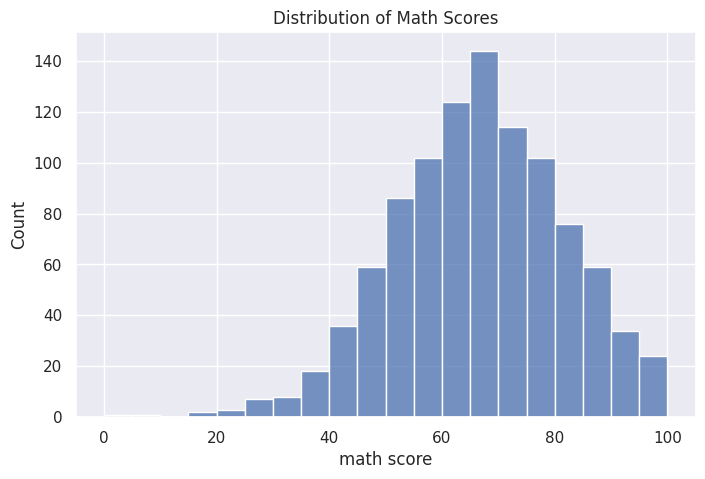

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['math score'], bins=20)
plt.title("Distribution of Math Scores")
plt.show()


- Shows how shipment sizes are distributed
- Right skew = many small shipments, few large ones

[### Distribution of Revenue
](https://)
> Add blockquote



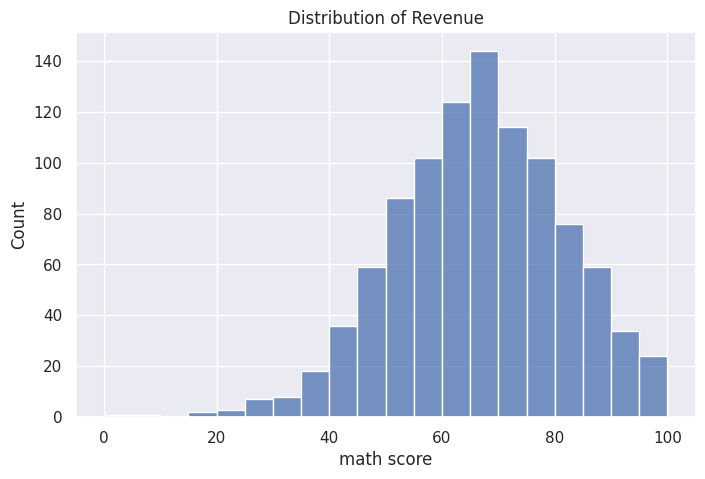

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['math score'], bins=20)
plt.title("Distribution of Revenue")
plt.show()




## Bivariate Analysis

### Math Score by Gender


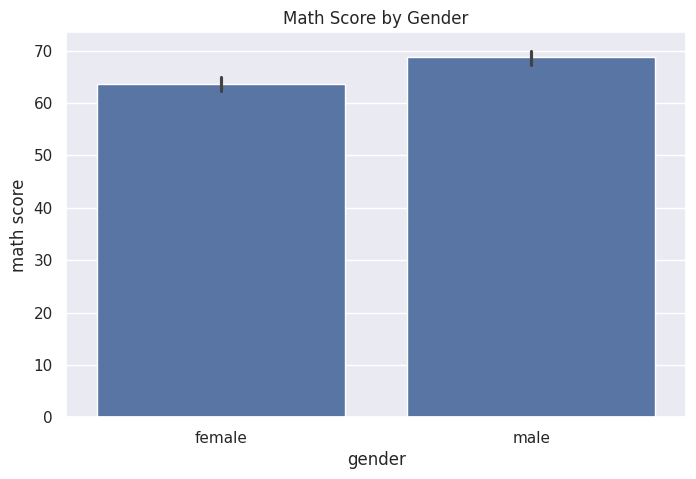

In [18]:
plt.figure(figsize=(8,5))
sns.barplot(x='gender', y='math score', data=df)
plt.title("Math Score by Gender")
plt.show()


### Average Math Score by Parental Education


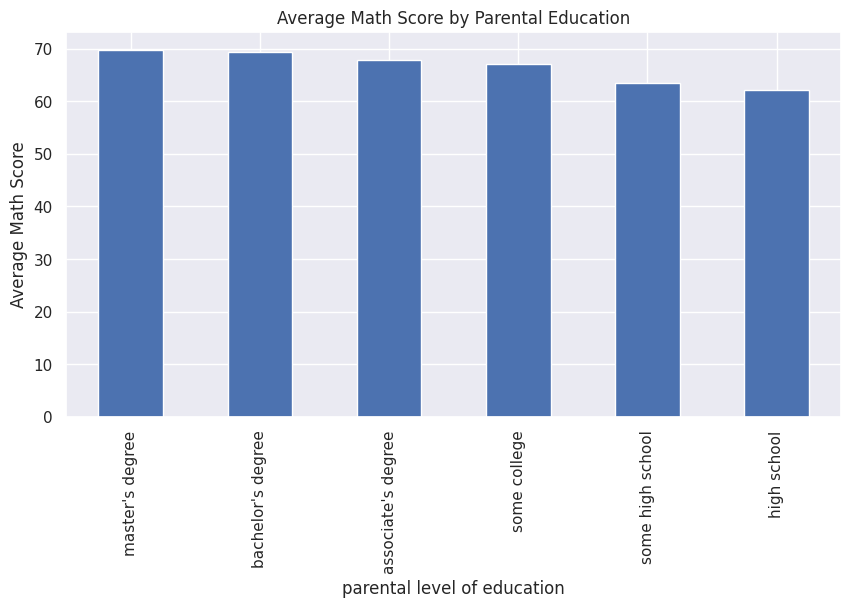

,math score
parental level of education,
master's degree,69.745763
bachelor's degree,69.389831
associate's degree,67.882883
some college,67.128319
some high school,63.497207
high school,62.137755


In [19]:
education_score = df.groupby('parental level of education')['math score'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
education_score.plot(kind='bar')
plt.title("Average Math Score by Parental Education")
plt.ylabel("Average Math Score")
plt.show()

education_score


### Top Average Scores by Gender




In [20]:
gender_scores = df.groupby('gender')['math score'].mean().sort_values(ascending=False)

gender_scores


,math score
gender,
male,68.728216
female,63.633205


### Math vs Reading Score Relationship




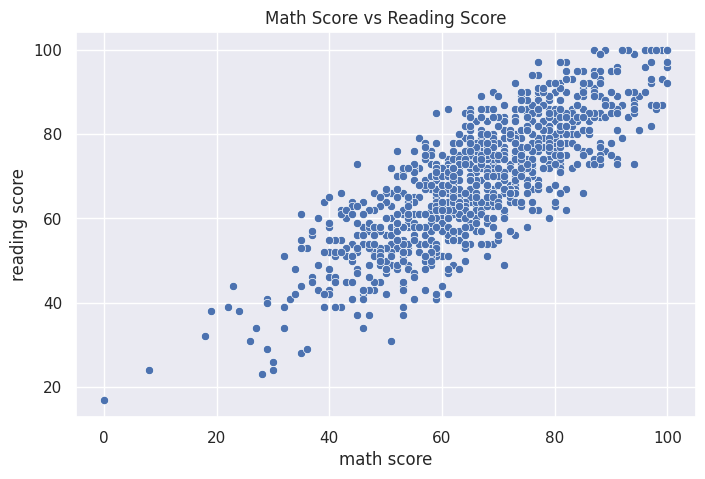

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='math score', y='reading score', data=df)
plt.title("Math Score vs Reading Score")
plt.show()


### Correlation Matrix

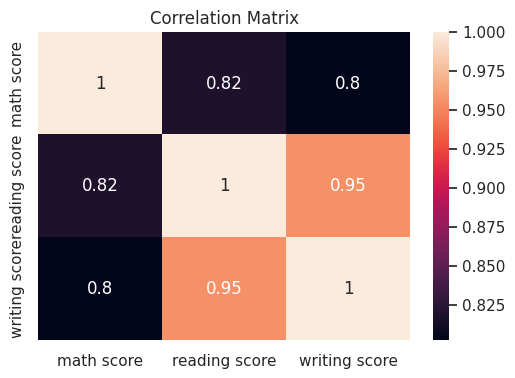

In [22]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['math score', 'reading score', 'writing score']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()


- Correlation close to 1 = strong positive relationship
- Close to 0 = weak relationship

## Multivariate Analysis
### Scores Distribution by Gender


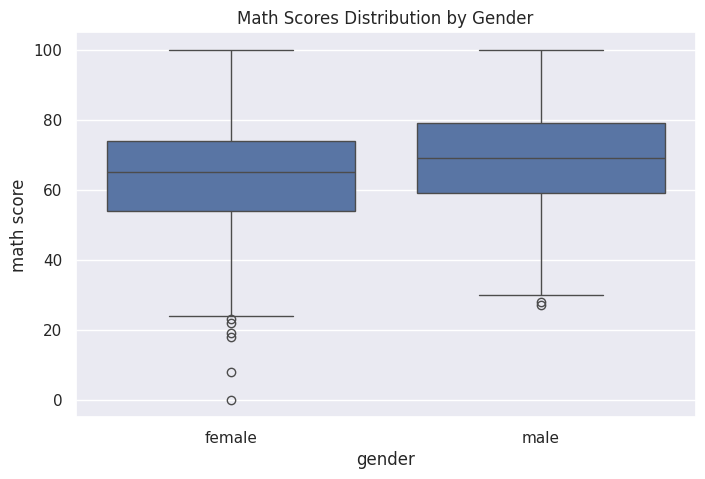

In [23]:
 plt.figure(figsize=(8,5))
sns.boxplot(x='gender', y='math score', data=df)
plt.title("Math Scores Distribution by Gender")
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the following to the assignment 1 folder.
1. Dataset file
2. Dataset Description readme file
2. Jupyter Notebook
